## Étape 1 : Importation des bibliothèques et chargement des données

**Objectif :**
Importer TensorFlow/Keras ainsi que les bibliothèques d'analyse, puis charger le jeu de données issu de l'étape `data_transformation.ipynb`.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Chargement du jeu de données transformé
df = pd.read_csv('../data/processed/transformed_loan.csv')

# Séparation des features (X) et de la cible (y)
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Division Train (80%) / Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Forme de X_train : {X_train.shape}")
print(f"Forme de X_test  : {X_test.shape}")

Forme de X_train : (491, 19)
Forme de X_test  : (123, 19)


## Étape 2 : Construction de l'architecture du réseau de neurones

**Architecture réseau :**
- **Couche d'entrée / 1ère couche dense :** 32 neurones, fonction d'activation `ReLU`.
- **Couche de Dropout :** 20% pour éviter le surapprentissage (*overfitting*).
- **2ème couche dense :** 16 neurones, fonction d'activation `ReLU`.
- **Couche de sortie :** 1 neurone, fonction d'activation `Sigmoid` (adaptée à la classification binaire : probabilité entre 0 et 1).

**Compilateur :**
- Optimiseur : `Adam`.
- Fonction de perte (*Loss*) : `binary_crossentropy`.
- Métrique : `accuracy`.

In [8]:
# Initialisation du modèle Séquentiel
model_dl = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Classification binaire
])

# Compilation du modèle
model_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Résumé de l'architecture
model_dl.summary()

c:\Users\MINA\Documents\eligibilte_pret_projet_ml\env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

## Étape 3 : Entraînement du modèle avec Early Stopping

**Objectif :**
Entraîner le réseau de neurones sur 100 époques avec un `EarlyStopping` qui stoppe l'entraînement automatiquement si la perte sur le jeu de validation cesse de s'améliorer pendant 10 époques consécutives.

In [9]:
# Configuration de l'EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

# Entraînement
history = model_dl.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.3523 - loss: 0.9931 - val_accuracy: 0.3333 - val_loss: 0.8250
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4623 - loss: 0.8061 - val_accuracy: 0.5203 - val_loss: 0.7030
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5662 - loss: 0.6885 - val_accuracy: 0.6748 - val_loss: 0.6402
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6293 - loss: 0.6559 - val_accuracy: 0.7480 - val_loss: 0.6087
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6965 - loss: 0.6295 - val_accuracy: 0.7561 - val_loss: 0.5881
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6904 - loss: 0.6101 - val_accuracy: 0.7724 - val_loss: 0.5683
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6965 - loss: 0.6189 - val_accuracy: 0.7805 - val_loss: 0.5530
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7067 - loss: 0.6079 - val_accuracy: 

## Étape 4 : Visualisation des courbes d'apprentissage (Loss & Accuracy)

**Objectif :**
Visualiser la courbe de perte (*Loss*) et la courbe de précision (*Accuracy*) au fil des époques pour vérifier l'absence d'overfitting.

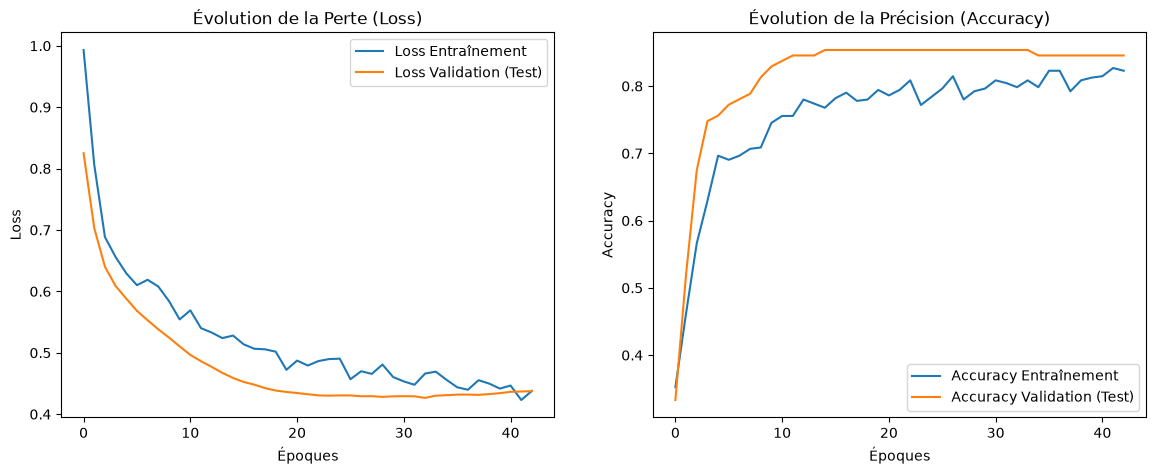

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique de la Perte (Loss)
axes[0].plot(history.history['loss'], label='Loss Entraînement')
axes[0].plot(history.history['val_loss'], label='Loss Validation (Test)')
axes[0].set_title('Évolution de la Perte (Loss)')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Graphique de la Précision (Accuracy)
axes[1].plot(history.history['accuracy'], label='Accuracy Entraînement')
axes[1].plot(history.history['val_accuracy'], label='Accuracy Validation (Test)')
axes[1].set_title('Évolution de la Précision (Accuracy)')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.show()

## Étape 5 : Évaluation détaillée et Matrice de Confusion

**Objectif :**
Convertir les probabilités prédites (0 à 1) en classes binaires (seuil à 0.5) pour afficher le rapport de classification et la matrice de confusion (VP, VN, FP, FN).

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
--- Résultats du Modèle Deep Learning ---
Vrais Négatifs (VN) : 21
Faux Positifs (FP)  : 17
Faux Négatifs (FN)  : 1
Vrais Positifs (VP) : 84

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



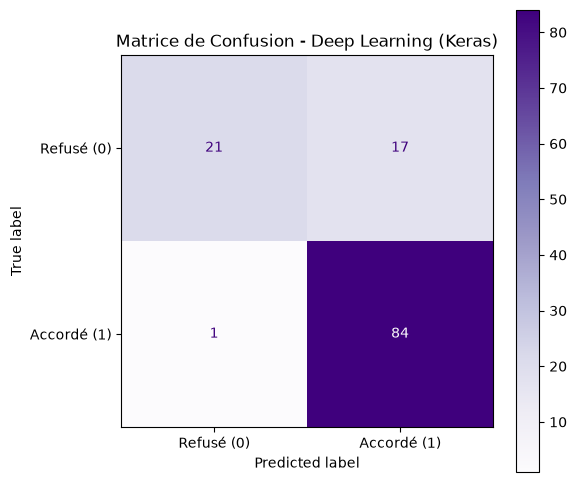

In [11]:
# Obtenir les probabilités prédites
y_pred_prob = model_dl.predict(X_test)

# Seuil de décision à 0.5
y_pred_dl = (y_pred_prob > 0.5).astype(int)

# Calcul des indicateurs de la matrice de confusion
cm_dl = confusion_matrix(y_test, y_pred_dl)
vn, fp, fn, vp = cm_dl.ravel()

print("--- Résultats du Modèle Deep Learning ---")
print(f"Vrais Négatifs (VN) : {vn}")
print(f"Faux Positifs (FP)  : {fp}")
print(f"Faux Négatifs (FN)  : {fn}")
print(f"Vrais Positifs (VP) : {vp}\n")

print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred_dl))

# Visualisation graphique de la Matrice de Confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dl, display_labels=["Refusé (0)", "Accordé (1)"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Purples", ax=ax)
plt.title("Matrice de Confusion - Deep Learning (Keras)")
plt.show()

## Étape 6 : Sauvegarde du modèle Deep Learning

**Objectif :**
Sauvegarder le modèle Deep Learning au format `.keras` dans le dossier `models/`.

In [12]:
import os

os.makedirs('../models', exist_ok=True)

# Sauvegarde au format standard Keras
model_dl.save('../models/dl_model.keras')
print(" Le modèle Deep Learning a été sauvegardé avec succès dans 'models/dl_model.keras' !")

 Le modèle Deep Learning a été sauvegardé avec succès dans 'models/dl_model.keras' !
